In [1]:
import sys
from pathlib import Path
sys.path.append(f"{Path().absolute().parent}")

In [2]:
from radp.utility.simulation_utils import seed_everything
seed_everything(1)

In [3]:
import numpy as np
from scipy import stats
from scipy.ndimage import correlate
from skimage.metrics import structural_similarity as ssim
from radp_library import *

In [4]:
WORKING_DIR = Path().absolute()
BUCKET_PATH = WORKING_DIR / "data"
SIM_DATA_PATH = Path("sim_data/tick_data")

In [5]:
sim_idx_folders = []

for i in range (0, 23):
    sim_idx_folders.append(f'tick_{i}')
    
print(sim_idx_folders)

['tick_0', 'tick_1', 'tick_2', 'tick_3', 'tick_4', 'tick_5', 'tick_6', 'tick_7', 'tick_8', 'tick_9', 'tick_10', 'tick_11', 'tick_12', 'tick_13', 'tick_14', 'tick_15', 'tick_16', 'tick_17', 'tick_18', 'tick_19', 'tick_20', 'tick_21', 'tick_22']


## If `full_data.csv` isn't available, run this to create it

In [6]:
# topology = pd.read_csv("data/sim_data/topology.csv")

# for i in range(0, len(sim_idx_folders)):
#     folder_name = f"tick_{i}"
#     folder_path = Path(BUCKET_PATH / SIM_DATA_PATH / folder_name)
    
#     file = f"generated_ue_data_for_cco_{i}.csv"
#     file_path = folder_path / file
    
#     config_file = f"site_config.csv"
#     config_file_path = folder_path / config_file
    
#     print(config_file_path)
    
#     if file_path.exists():
#         site_config = pd.read_csv(config_file_path)
        
#         ue_data = pd.read_csv(file_path)
#         ue_data_renamed = ue_data.copy().rename(columns={"lat": "latitude", "lon": "longitude"})
        
#         full_data = preprocess_ue_data(ue_data_renamed, topology)
#         full_data = full_data.rename(columns={"latitude": "loc_y", "longitude": "loc_x"})
        
#         full_data["cell_el_deg"] = site_config["cell_el_deg"].iloc[0]
        
#         output_path = folder_path / "full_data.csv"
#         full_data.to_csv(output_path, index=False)
        
#         print(f"Processed {file_path} and saved to {output_path}")
        
#     else:
#         print(f"File {file_path} does not exist")
        


     mock_ue_id      loc_x      loc_y  tick  ecgi site_id    cell_name  \
0            90 -73.999185  40.755219     0  1004   Site2  Site2_Cell2   
1           254 -73.995682  40.772806     0  1004   Site2  Site2_Cell2   
2           283 -74.005809  40.768744     0  1004   Site2  Site2_Cell2   
3           445 -73.983728  40.747291     0  1004   Site2  Site2_Cell2   
4           461 -74.004280  40.758975     0  1004   Site2  Site2_Cell2   
..          ...        ...        ...   ...   ...     ...          ...   
495         323 -73.990786  40.773899    22  1004   Site2  Site2_Cell2   
496         192 -73.959816  40.776757    22  1004   Site2  Site2_Cell2   
497         117 -73.996575  40.745939    22  1004   Site2  Site2_Cell2   
498          47 -73.959551  40.780129    22  1004   Site2  Site2_Cell2   
499         172 -73.998267  40.752066    22  1004   Site2  Site2_Cell2   

     enodeb_id  cell_az_deg  tac  ...  cell_lon  cell_id  \
0            2          150    1  ...  -121.757    

[2025-05-30 18:06:28,176] INFO:  Cuda enabled for training data.
[2025-05-30 18:06:29,127] INFO:  Iter 1/5 - Loss: 0.743 (delta=inf)
[2025-05-30 18:06:29,262] INFO:  Iter 2/5 - Loss: 0.724 (delta=-0.018136)
[2025-05-30 18:06:29,386] INFO:  Iter 3/5 - Loss: 0.706 (delta=-0.018361)
[2025-05-30 18:06:29,515] INFO:  Iter 4/5 - Loss: 0.688 (delta=-0.018540)
[2025-05-30 18:06:29,643] INFO:  Iter 5/5 - Loss: 0.669 (delta=-0.018563)
[2025-05-30 18:06:29,699] INFO:  Cuda enabled for training data.
[2025-05-30 18:06:29,836] INFO:  Iter 1/5 - Loss: 0.743 (delta=inf)
[2025-05-30 18:06:29,966] INFO:  Iter 2/5 - Loss: 0.725 (delta=-0.018133)
[2025-05-30 18:06:30,101] INFO:  Iter 3/5 - Loss: 0.706 (delta=-0.018310)
[2025-05-30 18:06:30,222] INFO:  Iter 4/5 - Loss: 0.688 (delta=-0.018608)
[2025-05-30 18:06:30,349] INFO:  Iter 5/5 - Loss: 0.669 (delta=-0.018613)
[2025-05-30 18:06:30,406] INFO:  Cuda enabled for training data.
[2025-05-30 18:06:30,535] INFO:  Iter 1/5 - Loss: 0.743 (delta=inf)
[2025-05-

KeyError: 5

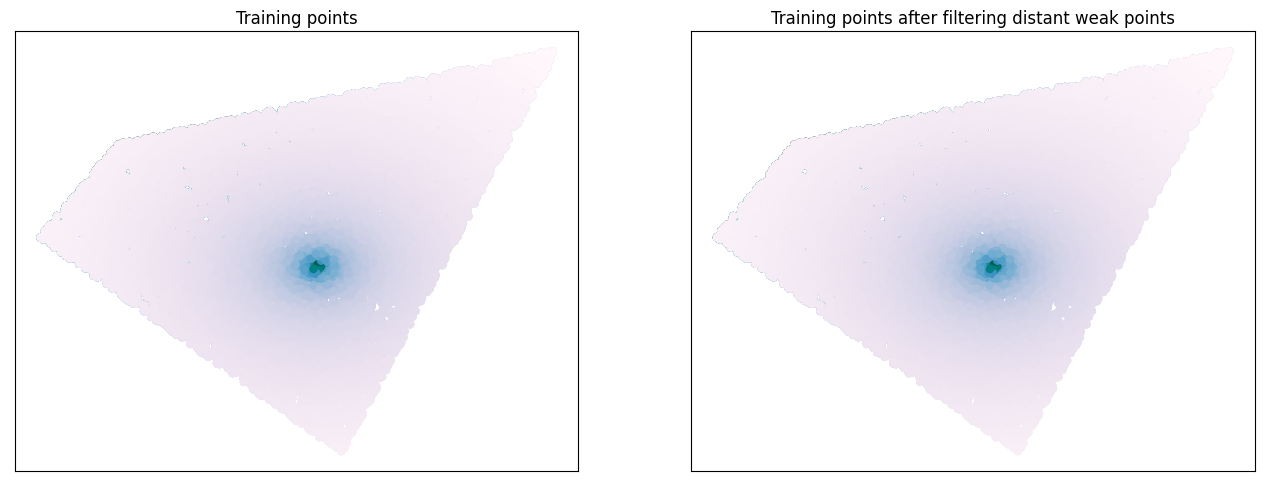

In [7]:
p_train_maxiter_dict = {
        40: [5]
}
p_test = 100

bayesian_digital_twins_list = []
test_data_list = []
pred_rsrp_list = []
MAE_list = []
Percentile85Error_list = []
p_train_list = []
maxiter_list = []


for p_train in p_train_maxiter_dict.keys():
    for maxiter in p_train_maxiter_dict[p_train]:
        logging.info(f"\n\nMAXITER = {maxiter}, p_train={p_train}\n")
        bayesian_digital_twins, site_config_df, test_data, loss_vs_iter, lons, lats, true_rsrp, pred_rsrp, MAE, Percentile85Error = bdt(
            bucket_path=BUCKET_PATH,
            sim_data_path=SIM_DATA_PATH,
            p_train=p_train,
            p_test=p_test,
            maxiter=maxiter,
            sim_idx_folders=sim_idx_folders,
            test_idx=2,
            plot_loss_vs_iter=True,
            choose_strongest_samples_percell=False,
            filter_out_samples_dbm_threshold=-70,
            filter_out_samples_kms_threshold=0.65,
        )
        bayesian_digital_twins_list.append(bayesian_digital_twins)
        test_data_list.append(test_data)
        p_train_list.append(p_train)
        maxiter_list.append(maxiter)
        pred_rsrp_list.append(pred_rsrp)
        MAE_list.append(MAE)
        Percentile85Error_list.append(Percentile85Error)
